In [2]:
import matplotlib.pyplot as plt

In [3]:
# Gates Data
r075_standard = [64, 68, 71, 70, 72]
r075_evolved = [72, 67, 71, 71, 71]

r100_standard = [55, 56, 57, 63, 62]
r100_evolved = [64, 58, 62, 66, 60]

r125_standard = [52, 52, 54, 53, 60]
r125_evolved = [60, 57, 56, 59, 58]

r150_standard = [47, 46, 48, 40, 53]
r150_evolved = [52, 50, 50, 55, 51]

gate_data = [r150_standard, r150_evolved, r125_standard, r125_evolved, r100_standard, r100_evolved, r075_standard, r075_evolved]

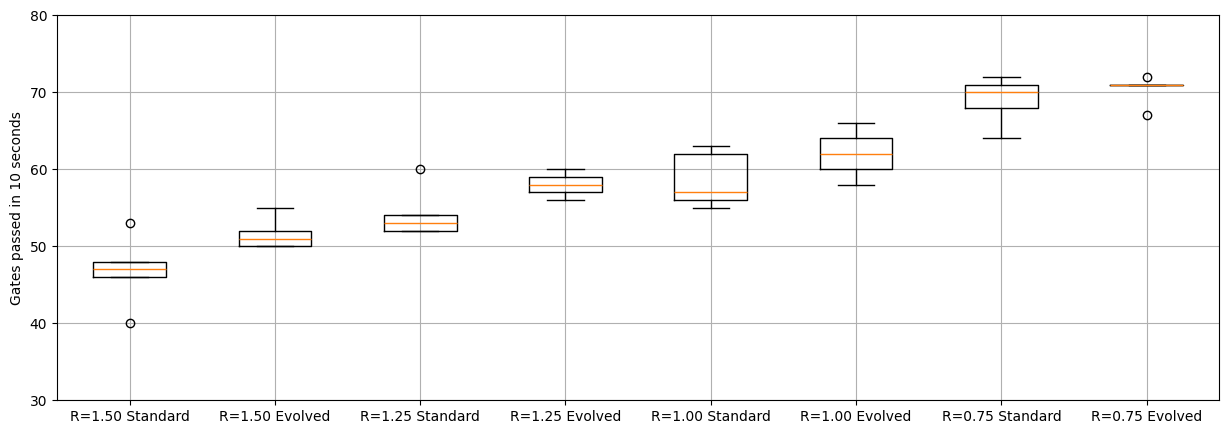

In [4]:
fig = plt.figure(figsize=(15,5))
ax = fig.add_subplot(111)

ax.boxplot(gate_data)

ax.set_xticklabels(['R=1.50 Standard', 'R=1.50 Evolved', 'R=1.25 Standard', 'R=1.25 Evolved', 'R=1.00 Standard', 'R=1.00 Evolved', 'R=0.75 Standard', 'R=0.75 Evolved'])
ax.set_ylabel('Gates passed in 10 seconds')

ax.set_ylim([30, 80])

ax.grid(True)

In [5]:
# Velocities
r075_standard = [7.53, 7.67, 8.26, 8,21, 8.39]
r075_evolved = [8.32, 7.82, 7.98, 8,10, 8.15]

r100_standard = [8.50, 8.19, 9.00, 9.56, 9.31]
r100_evolved = [9.28, 8.86, 9.37, 10.10, 9.28]

r125_standard = [9.67, 10.19, 10.70, 9.96, 11.19]
r125_evolved = [11.00, 10.71, 10.36, 11.09, 11.09]

r150_standard = [10.69, 10.19, 10.87, 10.01, 11.97]
r150_evolved = [11.62, 11.35, 11.61, 12.79, 11.56]

avg_speed = [r150_standard, r150_evolved, r125_standard, r125_evolved, r100_standard, r100_evolved, r075_standard, r075_evolved]

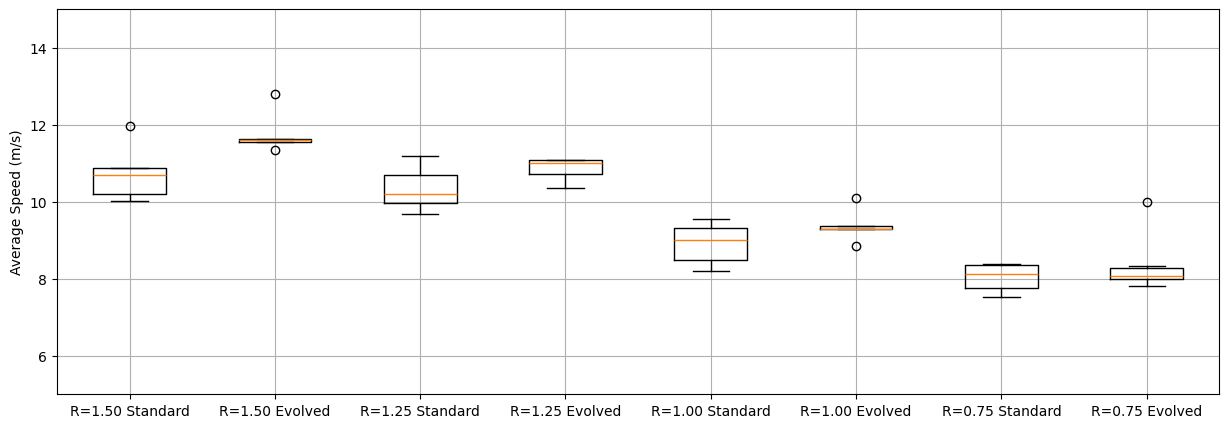

In [6]:
fig = plt.figure(figsize=(15,5))
ax = fig.add_subplot(111)

ax.boxplot(avg_speed)

ax.set_xticklabels(['R=1.50 Standard', 'R=1.50 Evolved', 'R=1.25 Standard', 'R=1.25 Evolved', 'R=1.00 Standard', 'R=1.00 Evolved', 'R=0.75 Standard', 'R=0.75 Evolved'])
ax.set_ylabel('Average Speed (m/s)')

ax.set_ylim([5, 15])

ax.grid(True)

In [7]:
import os
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

In [8]:
def load_tensorboard_data(log_dir, tag):
    """
    Load data from TensorBoard logs.
    
    Args:
        log_dir (str): Path to the directory containing TensorBoard logs.
        tag (str): The specific tag to extract (e.g., "rollout/ep_rew_mean").
    
    Returns:
        steps (list): List of steps (x-axis).
        values (list): List of values (y-axis).
    """
    event_acc = EventAccumulator(log_dir)
    event_acc.Reload()
    
    if tag not in event_acc.Tags()["scalars"]:
        raise ValueError(f"Tag '{tag}' not found in the logs at {log_dir}")
    
    events = event_acc.Scalars(tag)
    steps = [event.step for event in events]
    values = [event.value for event in events]
    
    return steps, values

In [16]:
# std_steps, std_reward = load_tensorboard_data('./logs/3_layers/r150_1E8/standard_quad_2_1', 'rollout/ep_rew_mean')
# evo_steps, evo_reward = load_tensorboard_data('./logs/3_layers/r150_1E8/evolved_quad_4_1', 'rollout/ep_rew_mean')

# std_steps, std_reward = load_tensorboard_data('./logs/3_layers_tau_2E8/r150/standard_drone_3_1', 'rollout/ep_rew_mean')
# lambda_steps, lambda_reward = load_tensorboard_data('./logs/3_layers_tau_2E8/r150/lambda_drone_1_1', 'rollout/ep_rew_mean')
# alpha_steps, alpha_reward = load_tensorboard_data('./logs/3_layers_tau_2E8/r125/alpha_drone_2_1', 'rollout/ep_rew_mean')
random_steps, random_reward = load_tensorboard_data('./logs/random/r150/p45t90_drone_3_1', 'rollout/ep_rew_mean')

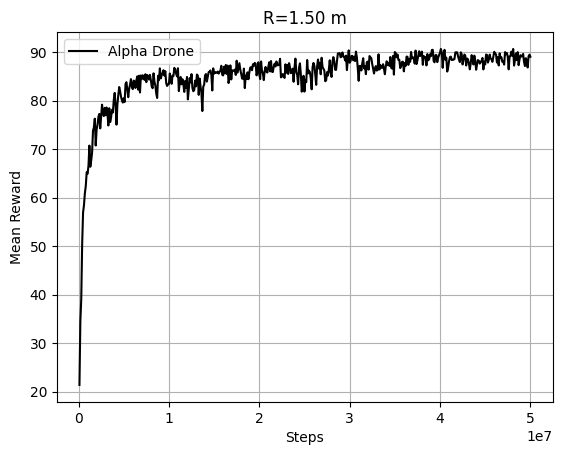

In [ ]:
plt.figure()
# plt.plot(std_steps, std_reward, label='Standard Drone', color='blue')
# plt.plot(lambda_steps, lambda_reward, label='Lambda Drone', color='red')
# plt.plot(alpha_steps, alpha_reward, label='Alpha Drone', color='black')
plt.plot(random_steps, random_reward, label='Random Drone', color='black')
plt.xlabel("Steps")
plt.ylabel("Mean Reward")
plt.title("R=1.50 m")
plt.legend()
plt.grid()

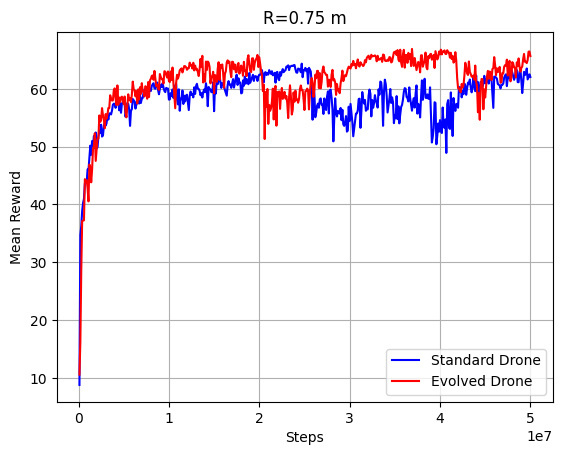

In [11]:
std_steps, std_reward = load_tensorboard_data('./logs/3_layers/r075_1E8/standard_quad_4_1', 'rollout/ep_rew_mean')
evo_steps, evo_reward = load_tensorboard_data('./logs/3_layers/r075_1E8/evolved_quad_4_1', 'rollout/ep_rew_mean')

plt.figure()
plt.plot(std_steps, std_reward, label='Standard Drone', color='blue')
plt.plot(evo_steps, evo_reward, label='Evolved Drone', color='red')
plt.xlabel("Steps")
plt.ylabel("Mean Reward")
plt.title("R=0.75 m")
plt.legend()
plt.grid()